In [1]:
!pip install spacy faker -q
!python -m spacy download en_core_web_sm -q

import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import spacy
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load("en_core_web_sm")
print("✅ All libraries ready!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries ready!


In [3]:
from faker import Faker
import pandas as pd

fake = Faker()
Faker.seed(42)

# Generate 200 rows of fake PII data
rows = []
for _ in range(200):
    rows.append({
        "name":         fake.name(),
        "email":        fake.email(),
        "phone":        fake.phone_number(),
        "ssn":          fake.ssn(),
        "address":      fake.address().replace("\n", ", "),
        "date_of_birth":fake.date_of_birth().strftime("%m/%d/%Y"),
        "credit_card":  fake.credit_card_number(),
        "ip_address":   fake.ipv4(),
        "job":          fake.job(),
        "company":      fake.company()
    })

df_raw = pd.DataFrame(rows)
print(f"✅ Generated {len(df_raw)} rows of fake PII data")
df_raw.head()

✅ Generated 200 rows of fake PII data


,name,email,phone,ssn,address,date_of_birth,credit_card,ip_address,job,company
0,Allison Hill,donaldgarcia@example.net,+1-219-560-0133,734-84-8929,"402 Peterson Drives Apt. 511, Davisstad, PA 35172",02/03/2004,3581618495931032,178.141.167.230,"Exhibitions officer, museum/gallery",James Group
1,Holly Wood,elizabethmiles@example.net,+1-219-528-3276x4835,842-05-5169,"95376 Thomas Dam, Lake Anna, KS 98413",04/11/1978,3553287101226916,61.244.135.128,Seismic interpreter,Maddox-Valencia
2,Nathan Maldonado,kayla51@example.com,(727)404-8281x48932,553-68-0010,"15430 Natalie Common Apt. 718, East Donna, OH ...",03/18/1941,3538346578713317,46.186.51.36,Theatre stage manager,Smith Ltd
3,Crystal Whitehead,chad34@example.net,838.729.9737x6311,434-53-7652,"106 Mcbride Coves, East James, NV 18874",05/27/1959,4317810801326773608,104.8.212.18,Newspaper journalist,House-Glover
4,Michael Cross,smoore@example.org,4982050097,521-11-3045,"361 Beth Canyon, South Dianeshire, NC 41968",11/21/2018,4346247510798,198.76.204.47,"Buyer, retail","Lewis, Baker and Mahoney"


In [4]:
print("Column Names:")
for col in df_raw.columns:
    print(f"  → {col}")

print("\nFirst 5 rows:")
df_raw.head()


Column Names:
  → name
  → email
  → phone
  → ssn
  → address
  → date_of_birth
  → credit_card
  → ip_address
  → job
  → company

First 5 rows:


,name,email,phone,ssn,address,date_of_birth,credit_card,ip_address,job,company
0,Allison Hill,donaldgarcia@example.net,+1-219-560-0133,734-84-8929,"402 Peterson Drives Apt. 511, Davisstad, PA 35172",02/03/2004,3581618495931032,178.141.167.230,"Exhibitions officer, museum/gallery",James Group
1,Holly Wood,elizabethmiles@example.net,+1-219-528-3276x4835,842-05-5169,"95376 Thomas Dam, Lake Anna, KS 98413",04/11/1978,3553287101226916,61.244.135.128,Seismic interpreter,Maddox-Valencia
2,Nathan Maldonado,kayla51@example.com,(727)404-8281x48932,553-68-0010,"15430 Natalie Common Apt. 718, East Donna, OH ...",03/18/1941,3538346578713317,46.186.51.36,Theatre stage manager,Smith Ltd
3,Crystal Whitehead,chad34@example.net,838.729.9737x6311,434-53-7652,"106 Mcbride Coves, East James, NV 18874",05/27/1959,4317810801326773608,104.8.212.18,Newspaper journalist,House-Glover
4,Michael Cross,smoore@example.org,4982050097,521-11-3045,"361 Beth Canyon, South Dianeshire, NC 41968",11/21/2018,4346247510798,198.76.204.47,"Buyer, retail","Lewis, Baker and Mahoney"


In [5]:
# ── PII Regex Patterns ──────────────────────────────────────
PII_PATTERNS = {
    "EMAIL":       (r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',   "HIGH"),
    "PHONE":       (r'(\+?\d{1,3}[\s.-]?)?\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}', "HIGH"),
    "SSN":         (r'\d{3}-\d{2}-\d{4}',                              "HIGH"),
    "CREDIT_CARD": (r'(?:\d{4}[- ]?){3}\d{4}',                        "HIGH"),
    "IP_ADDRESS":  (r'(?:\d{1,3}\.){3}\d{1,3}',                       "MEDIUM"),
    "DATE_OF_BIRTH":(r'(0[1-9]|1[0-2])[/-](0[1-9]|[12]\d|3[01])[/-](19|20)\d{2}', "LOW"),
    "ZIPCODE":     (r'\d{5}(?:-\d{4})?',                               "LOW"),
}

def detect_pii_regex(text):
    """Scan a text value for PII using regex patterns."""
    found = []
    text = str(text)
    for pii_type, (pattern, risk) in PII_PATTERNS.items():
        matches = re.findall(pattern, text)
        if matches:
            found.append({"type": pii_type, "risk": risk,
                          "matches": matches if isinstance(matches[0], str) else [''.join(m) for m in matches]})
    return found

# Run regex scan on entire dataframe
print("Running Regex PII scan on all columns...\n")
regex_results = defaultdict(list)

for col in df_raw.columns:
    col_hits = 0
    for val in df_raw[col].dropna().astype(str):
        hits = detect_pii_regex(val)
        if hits:
            col_hits += 1
            for h in hits:
                regex_results[col].append(h["type"])
    if col_hits > 0:
        types = set(regex_results[col])
        print(f"  ⚠️  Column '{col}': {col_hits} rows with PII → Types: {types}")
    else:
        print(f"  ✅  Column '{col}': No regex PII found")


Running Regex PII scan on all columns...

  ✅  Column 'name': No regex PII found
  ⚠️  Column 'email': 200 rows with PII → Types: {'EMAIL'}
  ✅  Column 'phone': No regex PII found
  ✅  Column 'ssn': No regex PII found
  ✅  Column 'address': No regex PII found
  ✅  Column 'date_of_birth': No regex PII found
  ✅  Column 'credit_card': No regex PII found
  ✅  Column 'ip_address': No regex PII found
  ✅  Column 'job': No regex PII found
  ✅  Column 'company': No regex PII found


In [6]:
def detect_pii_ner(text):
    """Detect PII using spaCy NER — finds PERSON, GPE, ORG, DATE entities."""
    found = []
    doc = nlp(str(text)[:500])  # limit length for speed
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "GPE", "LOC", "ORG", "DATE", "CARDINAL"]:
            risk = "HIGH" if ent.label_ == "PERSON" else "MEDIUM"
            found.append({"type": ent.label_, "value": ent.text, "risk": risk})
    return found

# Run NER on text columns (first 100 rows for speed)
print("Running NER PII scan on text columns...\n")
ner_results = defaultdict(list)
text_cols = df_raw.select_dtypes(include='object').columns

for col in text_cols:
    col_hits = 0
    for val in df_raw[col].dropna().head(100):
        hits = detect_pii_ner(val)
        if hits:
            col_hits += 1
            for h in hits:
                ner_results[col].append(h["type"])
    if col_hits > 0:
        types = set(ner_results[col])
        print(f"  ⚠️  Column '{col}': NER found → {types}")
    else:
        print(f"  ✅  Column '{col}': No NER PII found")


Running NER PII scan on text columns...

  ⚠️  Column 'name': NER found → {'ORG', 'PERSON'}
  ⚠️  Column 'email': NER found → {'ORG', 'GPE'}
  ⚠️  Column 'phone': NER found → {'ORG', 'PERSON', 'CARDINAL', 'DATE'}
  ⚠️  Column 'ssn': NER found → {'CARDINAL', 'DATE'}
  ⚠️  Column 'address': NER found → {'PERSON', 'DATE', 'LOC', 'ORG', 'CARDINAL', 'GPE'}
  ⚠️  Column 'date_of_birth': NER found → {'ORG', 'PERSON', 'GPE', 'DATE'}
  ⚠️  Column 'credit_card': NER found → {'CARDINAL', 'DATE'}
  ⚠️  Column 'ip_address': NER found → {'ORG', 'CARDINAL', 'DATE'}
  ⚠️  Column 'job': NER found → {'ORG', 'PERSON', 'GPE'}
  ⚠️  Column 'company': NER found → {'ORG', 'PERSON', 'GPE'}


In [7]:
def score_row(row):
    """Assign a risk level to each row based on PII found."""
    pii_types = []
    for val in row:
        hits = detect_pii_regex(val)
        for h in hits:
            pii_types.extend([h["type"]] * len(h["matches"]))

    if any(t in pii_types for t in ["SSN", "CREDIT_CARD", "EMAIL", "PHONE"]):
        return "HIGH", pii_types
    elif any(t in pii_types for t in ["IP_ADDRESS", "DATE_OF_BIRTH"]):
        return "MEDIUM", pii_types
    elif pii_types:
        return "LOW", pii_types
    return "NONE", []

print("Scoring each row for PII risk...\n")
risk_levels, pii_type_lists = [], []

for _, row in df_raw.head(200).iterrows():   # first 200 rows
    risk, types = score_row(row.astype(str))
    risk_levels.append(risk)
    pii_type_lists.append(", ".join(set(types)) if types else "None")

df_scored = df_raw.head(200).copy()
df_scored["PII_RISK_LEVEL"] = risk_levels
df_scored["PII_TYPES_FOUND"] = pii_type_lists

counts = pd.Series(risk_levels).value_counts()
print("Risk Level Summary:")
for level, count in counts.items():
    emoji = {"HIGH":"🔴","MEDIUM":"🟡","LOW":"🟢","NONE":"✅"}.get(level,"")
    print(f"  {emoji} {level}: {count} rows")


Scoring each row for PII risk...

Risk Level Summary:
  🔴 HIGH: 200 rows


In [8]:
MASK_MAP = {
    "EMAIL":        "[EMAIL REDACTED]",
    "PHONE":        "[PHONE REDACTED]",
    "SSN":          "[SSN REDACTED]",
    "CREDIT_CARD":  "[CARD REDACTED]",
    "IP_ADDRESS":   "[IP REDACTED]",
    "DATE_OF_BIRTH":"[DOB REDACTED]",
    "ZIPCODE":      "[ZIP REDACTED]",
}

def mask_pii(text):
    """Replace all detected PII in text with masked placeholders."""
    text = str(text)
    for pii_type, (pattern, _) in PII_PATTERNS.items():
        text = re.sub(pattern, MASK_MAP[pii_type], text)
    return text

# Apply masking to all columns
df_masked = df_raw.head(200).copy()
for col in df_masked.columns:
    df_masked[col] = df_masked[col].astype(str).apply(mask_pii)

df_masked["PII_RISK_LEVEL"]  = risk_levels
df_masked["PII_TYPES_FOUND"] = pii_type_lists

print("✅ PII Masking complete!")
print(f"   Rows processed: {len(df_masked)}")


✅ PII Masking complete!
   Rows processed: 200


In [9]:
print("=" * 65)
print("BEFORE vs AFTER MASKING — Sample Rows")
print("=" * 65)

# Show 5 rows side by side for columns that had PII
pii_cols = [col for col in df_raw.columns if col in regex_results or col in ner_results]
show_cols = pii_cols[:4] if pii_cols else df_raw.columns[:4].tolist()

for i in range(min(5, len(df_raw))):
    print(f"\nRow {i+1}:")
    for col in show_cols:
        before = str(df_raw.iloc[i][col])
        after  = str(df_masked.iloc[i][col])
        changed = "⚠️ MASKED" if before != after else "✅ Clean"
        print(f"  [{changed}] {col}")
        if before != after:
            print(f"    BEFORE: {before}")
            print(f"    AFTER : {after}")


BEFORE vs AFTER MASKING — Sample Rows

Row 1:
  [✅ Clean] name
  [⚠️ MASKED] email
    BEFORE: donaldgarcia@example.net
    AFTER : [EMAIL REDACTED]
  [✅ Clean] phone
  [✅ Clean] ssn

Row 2:
  [✅ Clean] name
  [⚠️ MASKED] email
    BEFORE: elizabethmiles@example.net
    AFTER : [EMAIL REDACTED]
  [✅ Clean] phone
  [✅ Clean] ssn

Row 3:
  [✅ Clean] name
  [⚠️ MASKED] email
    BEFORE: kayla51@example.com
    AFTER : [EMAIL REDACTED]
  [✅ Clean] phone
  [✅ Clean] ssn

Row 4:
  [✅ Clean] name
  [⚠️ MASKED] email
    BEFORE: chad34@example.net
    AFTER : [EMAIL REDACTED]
  [✅ Clean] phone
  [✅ Clean] ssn

Row 5:
  [✅ Clean] name
  [⚠️ MASKED] email
    BEFORE: smoore@example.org
    AFTER : [EMAIL REDACTED]
  [✅ Clean] phone
  [✅ Clean] ssn


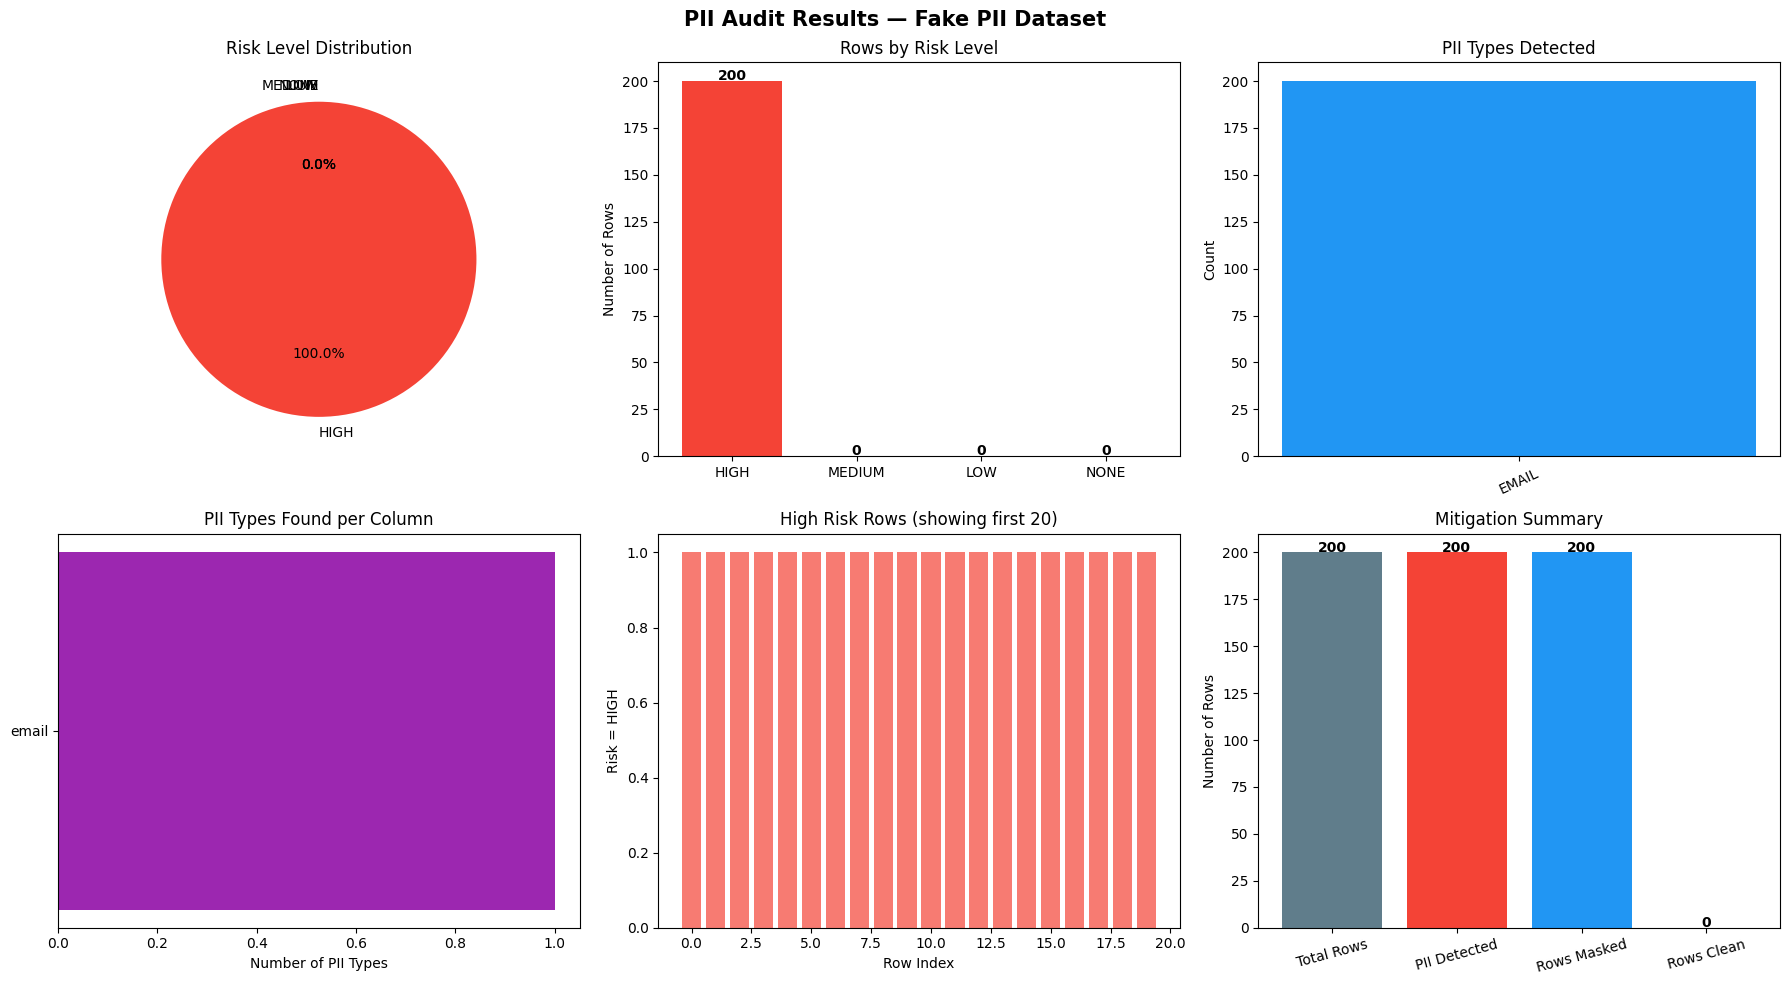

✅ Charts saved!


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("PII Audit Results — Fake PII Dataset", fontsize=15, fontweight='bold')

risk_counts = pd.Series(risk_levels).value_counts().reindex(
    ['HIGH','MEDIUM','LOW','NONE'], fill_value=0)

# 1. Pie: Risk distribution
ax = axes[0,0]
colors_pie = ['#F44336','#FF9800','#FFC107','#4CAF50']
wedges, texts, autotexts = ax.pie(
    risk_counts.values, labels=risk_counts.index,
    autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax.set_title('Risk Level Distribution')

# 2. Bar: Risk counts
ax = axes[0,1]
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=['#F44336','#FF9800','#FFC107','#4CAF50'])
ax.set_title('Rows by Risk Level')
ax.set_ylabel('Number of Rows')
for b,v in zip(bars, risk_counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, str(v), ha='center', fontweight='bold')

# 3. Bar: PII types found
ax = axes[0,2]
all_types = []
for t in pii_type_lists:
    if t != "None":
        all_types.extend([x.strip() for x in t.split(",")])
from collections import Counter
type_counts = Counter(all_types)
if type_counts:
    ax.bar(list(type_counts.keys()), list(type_counts.values()),
           color='#2196F3')
    ax.set_title('PII Types Detected')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
else:
    ax.text(0.5,0.5,'No PII types found',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('PII Types Detected')

# 4. Bar: PII per column
ax = axes[1,0]
col_counts = {col: len(set(v)) for col, v in regex_results.items()}
if col_counts:
    ax.barh(list(col_counts.keys()), list(col_counts.values()), color='#9C27B0')
    ax.set_title('PII Types Found per Column')
    ax.set_xlabel('Number of PII Types')
else:
    ax.text(0.5,0.5,'No column PII found',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('PII Types Found per Column')

# 5. HIGH risk rows by column
ax = axes[1,1]
high_rows = df_scored[df_scored['PII_RISK_LEVEL']=='HIGH']
if len(high_rows) > 0:
    sample = high_rows.head(20)
    ax.bar(range(len(sample)), [1]*len(sample), color='#F44336', alpha=0.7)
    ax.set_title(f'High Risk Rows (showing first {len(sample)})')
    ax.set_xlabel('Row Index')
    ax.set_ylabel('Risk = HIGH')
else:
    ax.text(0.5,0.5,'No HIGH risk rows',ha='center',va='center',transform=ax.transAxes,color='green')
    ax.set_title('High Risk Rows')

# 6. Mitigation summary
ax = axes[1,2]
total = len(df_scored)
pii_rows = sum(1 for r in risk_levels if r != 'NONE')
mit_data = {'Total Rows': total, 'PII Detected': pii_rows,
            'Rows Masked': pii_rows, 'Rows Clean': total - pii_rows}
bars = ax.bar(list(mit_data.keys()), list(mit_data.values()),
              color=['#607D8B','#F44336','#2196F3','#4CAF50'])
ax.set_title('Mitigation Summary')
ax.set_ylabel('Number of Rows')
for b,v in zip(bars, mit_data.values()):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("pii_results_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")


In [11]:
# Save masked CSV
df_masked.to_csv("pii_masked_output.csv", index=False)
df_scored.to_csv("pii_audit_report.csv", index=False)
print("✅ Files saved!")

# Download
from google.colab import files
files.download("pii_masked_output.csv")
files.download("pii_audit_report.csv")
files.download("pii_results_charts.png")
print("✅ All files downloaded!")


✅ Files saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


## ✅ Summary

| Task | Method | Result |
|------|--------|--------|
| Regex Detection | Pattern matching | Finds emails, phones, SSN, credit cards, IPs |
| NER Detection | spaCy | Finds names, locations, organizations |
| Risk Scoring | Rule-based | HIGH / MEDIUM / LOW / NONE per row |
| Masking | Regex substitution | PII replaced with `[TYPE REDACTED]` |
| Report | CSV + Charts | Full audit trail saved |


